In [1]:
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_enable_x64', True)

In [ ]:
import pandas as pd
import os

# 1. Define your input and output paths
# Make sure these point to where your CSVs are relative to the notebook!
o2_file = '/pscratch/sd/v/valer/ITU-R-P-676-to-transfer/R-REC-P.676-10-201309_table1.csv'
h2o_file = '/pscratch/sd/v/valer/ITU-R-P-676-to-transfer/R-REC-P.676-10-201309_table2.csv'

# Your target directory for the new Python module
output_dir = '/pscratch/sd/v/valer/atmo3/simulating_specific_attenuation_pycraf'
output_file = os.path.join(output_dir, 'itu_constants.py')

# Create the directory if it doesn't already exist
os.makedirs(output_dir, exist_ok=True)

# 2. Read the CSVs using the specific semicolon delimiter
# We set sep=';' because your files use semicolons instead of commas
o2_df = pd.read_csv(o2_file, sep=';')
h2o_df = pd.read_csv(h2o_file, sep=';')

def format_array(name, series):
    """Converts a pandas Series into a formatted jnp.array string"""
    # We use strip() just in case there are any trailing spaces in your CSVs
    values = ", ".join([str(val).strip() for val in series.values])
    return f"{name} = jnp.array([{values}])\n"
"""
# 3. Write the Python module directly to your target folder
with open(output_file, "w") as f:
    f.write('import jax.numpy as jnp\n\n')
    
    f.write('# ==============================================================================\n')
    f.write('# ITU-R P.676 Table 1: Oxygen Spectroscopic Data\n')
    f.write('# ==============================================================================\n')
    
    # Extract columns by their position (0 through 6)
    f.write(format_array('O2_f0', o2_df.iloc[:, 0]))
    f.write(format_array('O2_a1', o2_df.iloc[:, 1]))
    f.write(format_array('O2_a2', o2_df.iloc[:, 2]))
    f.write(format_array('O2_a3', o2_df.iloc[:, 3]))
    f.write(format_array('O2_a4', o2_df.iloc[:, 4]))
    f.write(format_array('O2_a5', o2_df.iloc[:, 5]))
    f.write(format_array('O2_a6', o2_df.iloc[:, 6]))
    
    f.write('''
O2_DATA = {
    'f0': O2_f0, 'a1': O2_a1, 'a2': O2_a2, 
    'a3': O2_a3, 'a4': O2_a4, 'a5': O2_a5, 'a6': O2_a6
}\n\n''')

    f.write('# ==============================================================================\n')
    f.write('# ITU-R P.676 Table 2: Water Vapor Spectroscopic Data\n')
    f.write('# ==============================================================================\n')
    
    # Extract columns by their position (0 through 6)
    f.write(format_array('H2O_f0', h2o_df.iloc[:, 0]))
    f.write(format_array('H2O_b1', h2o_df.iloc[:, 1]))
    f.write(format_array('H2O_b2', h2o_df.iloc[:, 2]))
    f.write(format_array('H2O_b3', h2o_df.iloc[:, 3]))
    f.write(format_array('H2O_b4', h2o_df.iloc[:, 4]))
    f.write(format_array('H2O_b5', h2o_df.iloc[:, 5]))
    f.write(format_array('H2O_b6', h2o_df.iloc[:, 6]))

    f.write('''
H2O_DATA = {
    'f0': H2O_f0, 'b1': H2O_b1, 'b2': H2O_b2, 
    'b3': H2O_b3, 'b4': H2O_b4, 'b5': H2O_b5, 'b6': H2O_b6
}\n''')

print(f"Successfully generated {output_file}!")
"""

Successfully generated /pscratch/sd/v/valer/atmo3/simulating_specific_attenuation_pycraf/itu_constants.py!


In [2]:
import jax.numpy as jnp

# ==============================================================================
# ITU-R P.676 Table 1: Oxygen Spectroscopic Data
# ==============================================================================
O2_f0 = jnp.array([50.474214, 50.987745, 51.50336, 52.021429, 52.542418, 53.066934, 53.595775, 54.130025, 54.67118, 55.221384, 55.783815, 56.264774, 56.363399, 56.968211, 57.612486, 58.323877, 58.446588, 59.164204, 59.590983, 60.306056, 60.434778, 61.150562, 61.800158, 62.41122, 62.486253, 62.997984, 63.568526, 64.127775, 64.67891, 65.224078, 65.764779, 66.302096, 66.836834, 67.369601, 67.900868, 68.431006, 68.960312, 118.750334, 368.498246, 424.76302, 487.249273, 715.392902, 773.83949, 834.145546])
O2_a1 = jnp.array([0.975, 2.529, 6.193, 14.32, 31.24, 64.29, 124.6, 227.3, 389.7, 627.1, 945.3, 543.4, 1331.8, 1746.6, 2120.1, 2363.7, 1442.1, 2379.9, 2090.7, 2103.4, 2438.0, 2479.5, 2275.9, 1915.4, 1503.0, 1490.2, 1078.0, 728.7, 461.3, 274.0, 153.0, 80.4, 39.8, 18.56, 8.172, 3.397, 1.334, 940.3, 67.4, 637.7, 237.4, 98.1, 572.3, 183.1])
O2_a2 = jnp.array([9.651, 8.653, 7.709, 6.819, 5.983, 5.201, 4.474, 3.8, 3.182, 2.618, 2.109, 0.014, 1.654, 1.255, 0.91, 0.621, 0.083, 0.387, 0.207, 0.207, 0.386, 0.621, 0.91, 1.255, 0.083, 1.654, 2.108, 2.617, 3.181, 3.8, 4.473, 5.2, 5.982, 6.818, 7.708, 8.652, 9.65, 0.01, 0.048, 0.044, 0.049, 0.145, 0.141, 0.145])
O2_a3 = jnp.array([6.69, 7.17, 7.64, 8.11, 8.58, 9.06, 9.55, 9.96, 10.37, 10.89, 11.34, 17.03, 11.89, 12.23, 12.62, 12.95, 14.91, 13.53, 14.08, 14.15, 13.39, 12.92, 12.63, 12.17, 15.13, 11.74, 11.34, 10.88, 10.38, 9.96, 9.55, 9.06, 8.58, 8.11, 7.64, 7.17, 6.69, 16.64, 16.4, 16.4, 16.0, 16.0, 16.2, 14.7])
O2_a4 = jnp.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
O2_a5 = jnp.array([2.566, 2.246, 1.947, 1.667, 1.388, 1.349, 2.227, 3.17, 3.558, 2.56, -1.172, 3.525, -2.378, -3.545, -5.416, -1.932, 6.768, -6.561, 6.957, -6.395, 6.342, 1.014, 5.014, 3.029, -4.499, 1.856, 0.658, -3.036, -3.968, -3.528, -2.548, -1.66, -1.68, -1.956, -2.216, -2.492, -2.773, -0.439, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
O2_a6 = jnp.array([6.85, 6.8, 6.729, 6.64, 6.526, 6.206, 5.085, 3.75, 2.654, 2.952, 6.135, -0.978, 6.547, 6.451, 6.056, 0.436, -1.273, 2.309, -0.776, 0.699, -2.825, -0.584, -6.619, -6.759, 0.844, -6.675, -6.139, -2.895, -2.59, -3.68, -5.002, -6.091, -6.393, -6.475, -6.545, -6.6, -6.65, 0.079, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

O2_DATA = {
    'f0': O2_f0, 'a1': O2_a1, 'a2': O2_a2, 
    'a3': O2_a3, 'a4': O2_a4, 'a5': O2_a5, 'a6': O2_a6
}

# ==============================================================================
# ITU-R P.676 Table 2: Water Vapor Spectroscopic Data
# ==============================================================================
H2O_f0 = jnp.array([22.23508, 67.80396, 119.99594, 183.310091, 321.225644, 325.152919, 336.222601, 380.197372, 390.134508, 437.346667, 439.150812, 443.018295, 448.001075, 470.888947, 474.689127, 488.491133, 503.568532, 504.482692, 547.67644, 552.02096, 556.936002, 620.700807, 645.866155, 658.00528, 752.033227, 841.053973, 859.962313, 899.306675, 902.616173, 906.207325, 916.171582, 923.118427, 970.315022, 987.926764, 1780.0])
H2O_b1 = jnp.array([0.113, 0.0012, 0.0008, 2.42, 0.0483, 1.499, 0.0011, 11.52, 0.0046, 0.065, 0.9218, 0.1976, 10.32, 0.3297, 1.262, 0.252, 0.039, 0.013, 9.701, 14.77, 487.4, 5.012, 0.0713, 0.3022, 239.6, 0.014, 0.1472, 0.0605, 0.0426, 0.1876, 8.34, 0.0869, 8.972, 132.1, 22300.0])
H2O_b2 = jnp.array([2.143, 8.735, 8.356, 0.668, 6.181, 1.54, 9.829, 1.048, 7.35, 5.05, 3.596, 5.05, 1.405, 3.599, 2.381, 2.853, 6.733, 6.733, 0.114, 0.114, 0.159, 2.2, 8.58, 7.82, 0.396, 8.18, 7.989, 7.917, 8.432, 5.111, 1.442, 10.22, 1.92, 0.258, 0.952])
H2O_b3 = jnp.array([28.11, 28.58, 29.48, 30.5, 23.03, 27.83, 26.93, 28.73, 21.52, 18.45, 21.0, 18.6, 26.32, 21.52, 23.55, 26.02, 16.12, 16.12, 26.0, 26.0, 32.1, 24.38, 18.0, 32.1, 30.6, 15.9, 30.6, 29.85, 28.65, 24.08, 26.7, 29.0, 25.5, 29.85, 176.2])
H2O_b4 = jnp.array([0.69, 0.69, 0.7, 0.64, 0.67, 0.68, 0.69, 0.54, 0.63, 0.6, 0.63, 0.6, 0.66, 0.66, 0.65, 0.69, 0.61, 0.61, 0.7, 0.7, 0.69, 0.71, 0.6, 0.69, 0.68, 0.33, 0.68, 0.68, 0.7, 0.7, 0.7, 0.7, 0.64, 0.68, 0.5])
H2O_b5 = jnp.array([4.8, 4.93, 4.78, 5.3, 4.69, 4.85, 4.74, 5.38, 4.81, 4.23, 4.29, 4.23, 4.84, 4.57, 4.65, 5.04, 3.98, 4.01, 4.5, 4.5, 4.11, 4.68, 4.0, 4.14, 4.09, 5.76, 4.09, 4.53, 5.1, 4.7, 4.78, 5.0, 4.94, 4.55, 30.5])
H2O_b6 = jnp.array([1.0, 0.82, 0.79, 0.85, 0.54, 0.74, 0.61, 0.89, 0.55, 0.48, 0.52, 0.5, 0.67, 0.65, 0.64, 0.72, 0.43, 0.45, 1.0, 1.0, 1.0, 0.68, 0.5, 1.0, 0.84, 0.45, 0.84, 0.9, 0.95, 0.53, 0.78, 0.8, 0.67, 0.9, 5.0])

H2O_DATA = {
    'f0': H2O_f0, 'b1': H2O_b1, 'b2': H2O_b2, 
    'b3': H2O_b3, 'b4': H2O_b4, 'b5': H2O_b5, 'b6': H2O_b6
}


In [ ]:


import jax
import jax.numpy as jnp
from functools import partial

# Import the pre-loaded ITU constants we generated from the CSVs
#from .itu_constants import O2_DATA, H2O_DATA

# ==============================================================================
# 1. Point-wise Physics Core (ITU-R P.676-13 Annex 1)
# ==============================================================================

def compute_attenuation_point(T, P, e, freqs_GHz, o2_data, h2o_data):
    """
    Computes the specific attenuation for a single spatial point over multiple frequencies.
    Input scalars: T (Kelvin), P (hPa, dry air pressure), e (hPa, water vapor pressure).
    Input vector: freqs_GHz (shape: Nf,)
    Returns: gamma_dry, gamma_wet (both shape: Nf,)
    """
    # Expand freqs for matrix broadcasting against spectral lines
    # f shape: (Nf, 1)
    f = freqs_GHz[:, None] 
    
    # Temperature parameter
    theta = 300.0 / T
    
    # --- Oxygen Calculation ---
    f_o2 = o2_data['f0'][None, :] # Shape: (1, N_o2_lines), frequency of each oxygen line
    
    # Line strength
    S_o2 = o2_data['a1'] * 1e-7 * P * (theta**3) * jnp.exp(o2_data['a2'] * (1 - theta)) # Eq (3) from ITU-R P.676-13 Annex 1
    
    # Line width and Zeeman broadening
    df_o2 = o2_data['a3'] * 1e-4 * (P * (theta**(0.8 - o2_data['a4'])) + 1.1 * e * theta) # Eq (6a) from ITU-R P.676-13 Annex 1
    df_o2 = jnp.sqrt(df_o2**2 + 2.25e-6) # Eq (6b) from ITU-R P.676-13 Annex 1
    
    # Interference factor
    delta_o2 = (o2_data['a5'] + o2_data['a6'] * theta) * 1e-4 * (P + e) * (theta**0.8) # Eq (7) from ITU-R P.676-13 Annex 1
    
    # Line shape (Van Vleck-Weisskopf)
    num1 = df_o2 - delta_o2 * (f_o2 - f)
    den1 = (f_o2 - f)**2 + df_o2**2
    num2 = df_o2 - delta_o2 * (f_o2 + f)
    den2 = (f_o2 + f)**2 + df_o2**2
    F_o2 = (f / f_o2) * ((num1 / den1) + (num2 / den2)) # Eq (5) from ITU-R P.676-13 Annex 1
    
    # Sum over all lines (axis 1 collapses the lines, leaving shape Nf)
    N_pp_o2_lines = jnp.sum(S_o2 * F_o2, axis=1) # You sum over the lines
    
    # Dry Continuum (Debye spectrum + nitrogen attenuation)
    d = 5.6e-4 * (P + e) * (theta**0.8) #eq (9) from ITU-R P.676-13 Annex 1
    term1 = 6.14e-5 / (d * (1 + (freqs_GHz / d)**2))
    term2 = (1.4e-12 * P * (theta**1.5)) / (1 + 1.9e-5 * (freqs_GHz**1.5))
    N_pp_D = freqs_GHz * P * (theta**2) * (term1 + term2) # Eq (8) from ITU-R P.676-13 Annex 1
    
    gamma_dry = 0.1820 * freqs_GHz * (N_pp_o2_lines + N_pp_D) # Eq (1) and (2a) from ITU-R P.676-13 Annex 1


    # --- Water Vapor Calculation ---
    f_h2o = h2o_data['f0'][None, :] #frequency of each water vapor line, shape: (1, N_h2o_lines)
    
    # Line strength
    S_h2o = h2o_data['b1'] * 1e-1 * e * (theta**3.5) * jnp.exp(h2o_data['b2'] * (1 - theta)) # Eq (3) from ITU-R P.676-13 Annex 1
    
    # Line width and Doppler broadening
    df_h2o = h2o_data['b3'] * 1e-4 * (P * (theta**h2o_data['b4']) + h2o_data['b5'] * e * (theta**h2o_data['b6'])) # Eq (6a) from ITU-R P.676-13 Annex 1
    df_h2o = 0.535 * df_h2o + jnp.sqrt(0.217 * (df_h2o**2) + (2.1316e-12 * (f_h2o**2)) / theta) # Eq (6b) from ITU-R P.676-13 Annex 1
    
    # Line shape (interference factor delta is 0 for H2O)
    num1_w = df_h2o
    den1_w = (f_h2o - f)**2 + df_h2o**2
    num2_w = df_h2o
    den2_w = (f_h2o + f)**2 + df_h2o**2
    F_h2o = (f / f_h2o) * ((num1_w / den1_w) + (num2_w / den2_w)) # Eq (5) from ITU-R P.676-13 Annex 1, but with delt_H2O=0 for water vapor lines
    
    # Sum over all water vapor lines
    N_pp_h2o = jnp.sum(S_h2o * F_h2o, axis=1)
    
    gamma_wet = 0.1820 * freqs_GHz * N_pp_h2o # Eq (1) and (2b) from ITU-R P.676-13 Annex 1
    
    return gamma_dry, gamma_wet


# ==============================================================================
# 2. 3D Spatial Vectorization (Direct 4D Output)
# ==============================================================================

# Stack jax.vmap three times to map over the Z, Y, and X axes of your 3D cubes.
# The 'None' arguments ensure the frequencies and spectroscopic dicts aren't mapped over.
compute_1d = jax.vmap(compute_attenuation_point, in_axes=(0, 0, 0, None, None, None))
compute_2d = jax.vmap(compute_1d, in_axes=(0, 0, 0, None, None, None))
compute_3d = jax.vmap(compute_2d, in_axes=(0, 0, 0, None, None, None))

@partial(jax.jit, static_argnames=['o2_data', 'h2o_data'])
def compute_3d_attenuation(T_grid, P_grid, e_grid, freqs_GHz, o2_data=O2_DATA, h2o_data=H2O_DATA):
    """
    Computes specific attenuation over a full 3D grid simultaneously.
    
    Input grids: T_grid, P_grid, e_grid of shape (Nx, Ny, Nz)
    Input freq: freqs_GHz of shape (Nf,)
    Returns: gamma_dry, gamma_wet of shape (Nx, Ny, Nz, Nf)
    """
    return compute_3d(T_grid, P_grid, e_grid, freqs_GHz, o2_data, h2o_data)

In [8]:
import jax
import jax.numpy as jnp

# Import your newly created JAX physics module

# 1. Define grid dimensions and frequency array
# Using a small spatial grid (10x10) with 50 altitude layers
Nx, Ny, Nz = 10, 10, 50 

# Frequencies from 1 GHz to 999 GHz (100 bins)
freqs_GHz = jnp.linspace(1.0, 999.0, 100)

# 2. Create realistic 1D vertical profiles (Length = Nz)
# Temperature drops from 290 K (ground) to 220 K (top)
T_1d = jnp.linspace(290.0, 220.0, Nz)

# Dry Air Pressure drops exponentially from 1000 hPa to 100 hPa
P_1d = jnp.geomspace(1000.0, 100.0, Nz)

# Water Vapor Partial Pressure drops rapidly from 15 hPa to 0.1 hPa
e_1d = jnp.geomspace(15.0, 0.1, Nz)

# 3. Broadcast 1D profiles into 3D cubes of shape (Nx, Ny, Nz)
# This simulates a horizontally uniform atmosphere across X and Y
T_cube = jnp.broadcast_to(T_1d, (Nx, Ny, Nz))
P_cube = jnp.broadcast_to(P_1d, (Nx, Ny, Nz))
e_cube = jnp.broadcast_to(e_1d, (Nx, Ny, Nz))

# 4. Run the JAX compilation and physics calculation
print(f"Evaluating {Nx}x{Ny}x{Nz} grid across {len(freqs_GHz)} frequencies...")
print("Triggering JIT compilation (this might take a few seconds on the first run)...")

gamma_dry, gamma_wet = compute_3d_attenuation(T_cube, P_cube, e_cube, freqs_GHz)

# 5. Verify the outputs
print(f"\n--- SUCCESS! ---")
print(f"Output Gamma Dry Shape: {gamma_dry.shape}")
print(f"Output Gamma Wet Shape: {gamma_wet.shape}")

# 6. Sanity check: Print a value near the 22.23 GHz water vapor line at ground level (Z=0)
# In our linspace(1, 350, 100), 22 GHz is roughly at index 6
sample_f_idx = 100
f_val = freqs_GHz[sample_f_idx]

print(f"\nSample Attenuation at Ground Level (Z=0) for f = {f_val:.1f} GHz:")
print(f"  -> Dry Attenuation: {gamma_dry[0, 0, 0, sample_f_idx]:.5f} dB/km")
print(f"  -> Wet Attenuation: {gamma_wet[0, 0, 0, sample_f_idx]:.5f} dB/km")

print(f"\nSample Attenuation at Top of Atmosphere (Z={Nz-1}) for f = {f_val:.1f} GHz:")
print(f"  -> Dry Attenuation: {gamma_dry[0, 0, Nz-1, sample_f_idx]:.5f} dB/km")
print(f"  -> Wet Attenuation: {gamma_wet[0, 0, Nz-1, sample_f_idx]:.5f} dB/km")


Evaluating 10x10x50 grid across 100 frequencies...
Triggering JIT compilation (this might take a few seconds on the first run)...

--- SUCCESS! ---
Output Gamma Dry Shape: (10, 10, 50, 100)
Output Gamma Wet Shape: (10, 10, 50, 100)

Sample Attenuation at Ground Level (Z=0) for f = 999.0 GHz:
  -> Dry Attenuation: 0.17978 dB/km
  -> Wet Attenuation: 1198.48471 dB/km

Sample Attenuation at Top of Atmosphere (Z=49) for f = 999.0 GHz:
  -> Dry Attenuation: 0.00476 dB/km
  -> Wet Attenuation: 2.20313 dB/km


In [14]:
import pycraf
import astropy.units as u

#Let's set a sample point in our cube to test pycraf and compare it to our JAX implementation. We'll use the ground level (Z=0) and the same frequency we checked above (22.23 GHz).
i = 0  # Z=0 (ground level)

frequencies_GHZ = freqs_GHz * u.GHz  # Ensure frequencies is a Quantity in GHz

Temperature = T_1d[i] * u.K  # Ensure Temperature is a Quantity in K
P_dry = P_1d[i] * u.hPa  # Ensure P_dry is a Quantity in hPa
P_water = e_1d[i] * u.hPa  # Ensure P_water is a Quantity in hPa
#P   _dry = Pressure - P_water  # Ensure P_dry is a Quantity in hPa

alpha_dry_dB_km, alpha_wet_dB_km = pycraf.atm.atten_specific_annex1(
            frequencies_GHZ, P_dry, P_water, Temperature
        )

# Let's print the values at sample_f_idx to compare with our JAX implementation
print(f"\n--- Pycraf Attenuation at Ground Level (Z=0) for f = {f_val:.1f} GHz ---")
print(f"  -> Dry Attenuation: {alpha_dry_dB_km[sample_f_idx-1]:.5f} dB/km")
print(f"  -> Wet Attenuation: {alpha_wet_dB_km[sample_f_idx-1]:.5f} dB/km")   



--- Pycraf Attenuation at Ground Level (Z=0) for f = 999.0 GHz ---
  -> Dry Attenuation: 0.17978 dB / km dB/km
  -> Wet Attenuation: 1198.48471 dB / km dB/km


In [13]:
print(frequencies_GHZ[sample_f_idx-1])

999.0 GHz


In [6]:
from matplotlib import pyplot as plt
# 1. Update global parameters for presentation visibility
plt.rcParams.update({
    'font.size': 18,              # General font size for text
    'axes.labelsize': 20,         # Size of X and Y axis labels
    'axes.titlesize': 24,         # Size of the graph title
    'xtick.labelsize': 16,        # Size of the numbers on the X axis
    'ytick.labelsize': 16,        # Size of the numbers on the Y axis
    'legend.fontsize': 16,        # Size of the legend text
    'lines.linewidth': 3,       # Thicker lines for the plotted data
})

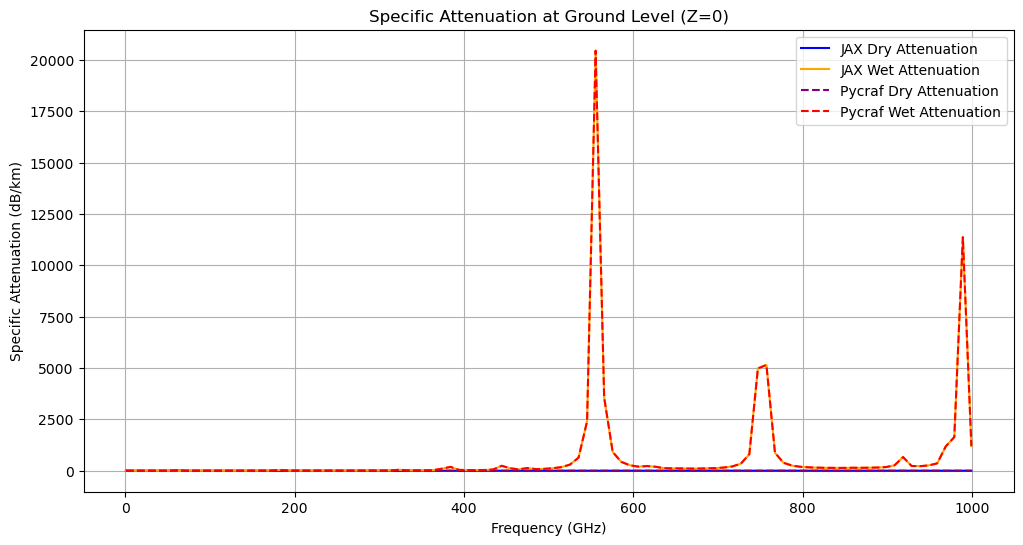

In [15]:
#Let's plot the sprectrum of attenuation at ground level (Z=0) for both dry and wet components, comparing JAX and pycraf results.
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(freqs_GHz, gamma_dry[0, 0, 0, :], label='JAX Dry Attenuation', color='blue')
plt.plot(freqs_GHz, gamma_wet[0, 0, 0, :], label='JAX Wet Attenuation', color='orange')
plt.plot(freqs_GHz, alpha_dry_dB_km, label='Pycraf Dry Attenuation', color='purple', linestyle='dashed')
plt.plot(freqs_GHz, alpha_wet_dB_km, label='Pycraf Wet Attenuation', color='red', linestyle='dashed')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Specific Attenuation (dB/km)')
plt.title('Specific Attenuation at Ground Level (Z=0)')
plt.legend()
plt.grid()
plt.show()

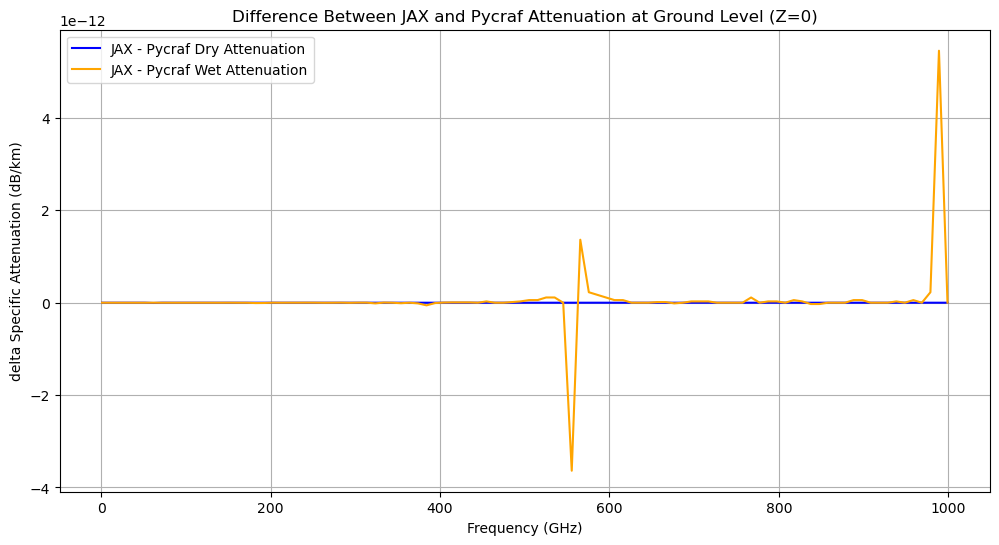

In [16]:
#Let's plot the difference between JAX and pycraf for both dry and wet components to see if there are any discrepancies.
plt.figure(figsize=(12, 6))
plt.plot(freqs_GHz, gamma_dry[0, 0, 0, :] - alpha_dry_dB_km, label='JAX - Pycraf Dry Attenuation', color='blue')
plt.plot(freqs_GHz, gamma_wet[0, 0, 0, :] - alpha_wet_dB_km, label='JAX - Pycraf Wet Attenuation', color='orange')
plt.xlabel('Frequency (GHz)')
plt.ylabel('delta Specific Attenuation (dB/km)')
plt.title('Difference Between JAX and Pycraf Attenuation at Ground Level (Z=0)')
plt.legend()
plt.grid()
plt.show()

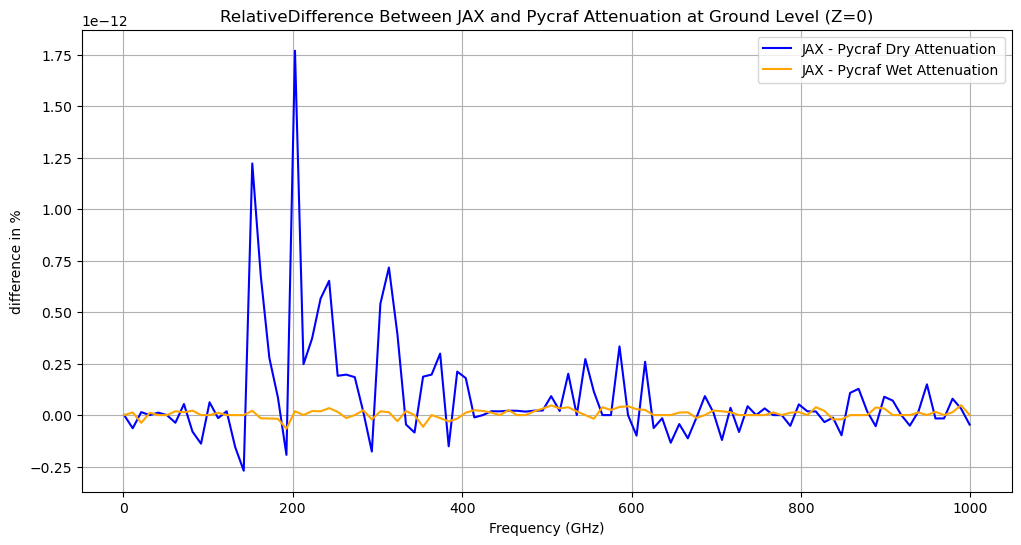

In [18]:
#Let's plot the difference between JAX and pycraf for both dry and wet components to see if there are any discrepancies.
plt.figure(figsize=(12, 6))
plt.plot(freqs_GHz, (gamma_dry[0, 0, 0, :] - alpha_dry_dB_km)/alpha_dry_dB_km*100, label='JAX - Pycraf Dry Attenuation', color='blue')
plt.plot(freqs_GHz, (gamma_wet[0, 0, 0, :] - alpha_wet_dB_km)/alpha_wet_dB_km*100, label='JAX - Pycraf Wet Attenuation', color='orange')
plt.xlabel('Frequency (GHz)')
plt.ylabel('difference in %')
plt.title('RelativeDifference Between JAX and Pycraf Attenuation at Ground Level (Z=0)')
plt.legend()
plt.grid()
plt.show()